# LA Parking Citations Data Pipeline

A Databricks and PySpark data engineering project using public Los Angeles parking citation data.

This pipeline ingests citation records from the LA Open Data API, preserves raw source data in a Bronze Delta table, cleans and types the data into a Silver layer, and will enrich citations with Los Angeles district boundary data for geospatial analysis.

### Pipeline

**LA Open Data API**  
↓  
**Python API ingestion**  
↓  
**PySpark DataFrame**  
↓  
**Bronze Delta Table** — source-preserving records  
↓  
**Silver Delta Table** — cleaned and typed records  
↓  
**District Boundary Enrichment** — spatial join *(next)*  
↓  
**Gold Delta Table** — analytics-ready data

## 1. API Ingestion
Fetch a small sample from the LA Open Data API and preserve the source representation.

In [0]:
%pip install geopandas

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%restart_python

In [0]:
import requests

# Fetch a very small sample first so we can inspect the source structure
# before scaling the ingestion up to thousands or millions of records.

API_LIMIT = 50000
OFFSET = 200000

url = "https://data.lacity.org/resource/4f5p-udkv.json"
params = {
        "$limit": API_LIMIT,
        "$offset": OFFSET,
           }

response = requests.get(url, params=params)
response.raise_for_status()

raw_data = response.json()


## 2. Bronze Schema
Define an explicit ingestion schema rather than relying on Spark schema inference.

In [0]:
from pyspark.sql.types import (
    StructType,
    StructField,
    StringType
)

# Bronze layer: preserve the API response as close to the source as possible.
# Socrata returns many numeric-looking fields as strings, so all source fields
# are ingested as strings here and cast to appropriate types in Silver.
schema = StructType([
    StructField("ticket_number", StringType(), True),
    StructField("issue_date", StringType(), True),
    StructField("issue_time", StringType(), True),
    StructField("meter_id", StringType(), True),
    StructField("marked_time", StringType(), True),
    StructField("rp_state_plate", StringType(), True),
    StructField("plate_expiry_date", StringType(), True),
    StructField("vin", StringType(), True),
    StructField("make", StringType(), True),
    StructField("body_style", StringType(), True),
    StructField("color", StringType(), True),
    StructField("location", StringType(), True),
    StructField("route", StringType(), True),
    StructField("agency", StringType(), True),
    StructField("violation_code", StringType(), True),
    StructField("violation_description", StringType(), True),
    StructField("fine_amount", StringType(), True),
    StructField("agency_desc", StringType(), True),
    StructField("color_desc", StringType(), True),
    StructField("body_style_desc", StringType(), True),
    StructField("loc_lat", StringType(), True),
    StructField("loc_long", StringType(), True),
    StructField("geocodelocation", StringType(), True)
])

In [0]:
# The geocodelocation field is returned as a nested object.
# Store it as a string for Bronze so ingestion remains simple;
# we can parse or replace it later using loc_lat and loc_long.
for record in raw_data:
    if "geocodelocation" in record:
        record["geocodelocation"] = str(record["geocodelocation"])

In [0]:
from pyspark.sql import functions as F

df = spark.createDataFrame(raw_data, schema=schema)

df = (
    df
    .withColumn("issue_time", F.col("issue_time").cast("double"))
    .withColumn("agency", F.col("agency").cast("double"))
    .withColumn("fine_amount", F.col("fine_amount").cast("double"))
)

In [0]:
display(df.head())
df.printSchema()

Row(ticket_number='4603856084', issue_date='2025-05-31T00:00:00.000', issue_time=2113.0, meter_id=None, marked_time='0000', rp_state_plate='CA', plate_expiry_date='202408', vin=None, make='JEEP', body_style='PA', color='GY', location='850 7TH ST W', route=None, agency=56.0, violation_code='5200', violation_description='DISPLAY OF PLATES', fine_amount=25.0, agency_desc='56 - DOT - CENTRAL', color_desc='GREY', body_style_desc='PASSENGER CAR', loc_lat='34.0390366', loc_long='-118.2447298', geocodelocation="{'type': 'Point', 'coordinates': [-118.2447298, 34.0390366]}")

root
 |-- ticket_number: string (nullable = true)
 |-- issue_date: string (nullable = true)
 |-- issue_time: double (nullable = true)
 |-- meter_id: string (nullable = true)
 |-- marked_time: string (nullable = true)
 |-- rp_state_plate: string (nullable = true)
 |-- plate_expiry_date: string (nullable = true)
 |-- vin: string (nullable = true)
 |-- make: string (nullable = true)
 |-- body_style: string (nullable = true)
 |-- color: string (nullable = true)
 |-- location: string (nullable = true)
 |-- route: string (nullable = true)
 |-- agency: double (nullable = true)
 |-- violation_code: string (nullable = true)
 |-- violation_description: string (nullable = true)
 |-- fine_amount: double (nullable = true)
 |-- agency_desc: string (nullable = true)
 |-- color_desc: string (nullable = true)
 |-- body_style_desc: string (nullable = true)
 |-- loc_lat: string (nullable = true)
 |-- loc_long: string (nullable = true)
 |-- geocodelocation: string (nullable = true)



## 3. Data Quality Profiling
Inspect completeness and geographic fields before persisting the Bronze layer.

Count nulls in important fields, remove or flag records where missing values make the record unusable.

In [0]:
# null count by column
# Remove fields with limited analytical value for this pipeline.
# The source API remains authoritative; this project retains fields needed
# for citation analysis and geographic enrichment.
from pyspark.sql import functions as F

df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+-------------+----------+----------+--------+-----------+--------------+-----------------+-----+----+----------+-----+--------+-----+------+--------------+---------------------+-----------+-----------+----------+---------------+-------+--------+---------------+
|ticket_number|issue_date|issue_time|meter_id|marked_time|rp_state_plate|plate_expiry_date|  vin|make|body_style|color|location|route|agency|violation_code|violation_description|fine_amount|agency_desc|color_desc|body_style_desc|loc_lat|loc_long|geocodelocation|
+-------------+----------+----------+--------+-----------+--------------+-----------------+-----+----+----------+-----+--------+-----+------+--------------+---------------------+-----------+-----------+----------+---------------+-------+--------+---------------+
|            0|         0|         0|   40971|          0|             0|                0|50000| 296|      2505|  534|      25|43761|     0|          1061|                 1061|          0|          0|      252

Check for rows that are completely identical, then ticket number duplication.

In [0]:
# Check row count before deduplication
rows_before = df.count()

# check for exact duplicate records
df_clean = df.dropDuplicates()

rows_after = df_clean.count()

print(f"Rows before deduplication: {rows_before:,}")
print(f"Rows after deduplication:  {rows_after:,}")
print(f"Duplicates removed:        {rows_before - rows_after:,}")

Rows before deduplication: 50,000
Rows after deduplication:  50,000
Duplicates removed:        0


In [0]:
# Check for duplicate citation identifiers
df_clean.groupBy("ticket_number") \
    .count() \
    .filter("count > 1") \
    .orderBy("count", ascending=False) \
    .show()

+-------------+-----+
|ticket_number|count|
+-------------+-----+
+-------------+-----+



Domain and Validity Checks

## 4. Bronze Layer
Persist source-aligned citation records as a managed Delta table.

In [0]:
%sql
DROP TABLE IF EXISTS parking_citations_bronze;

In [0]:
# create managed bronze parking_citations_bronze

df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("parking_citations_bronze")

In [0]:
spark.table("parking_citations_bronze").show(5)

+-------------+--------------------+----------+--------+-----------+--------------+-----------------+----+----+----------+-----+--------------------+-----+------+--------------+---------------------+-----------+-----------+----------+---------------+----------+------------+--------------------+
|ticket_number|          issue_date|issue_time|meter_id|marked_time|rp_state_plate|plate_expiry_date| vin|make|body_style|color|            location|route|agency|violation_code|violation_description|fine_amount|agency_desc|color_desc|body_style_desc|   loc_lat|    loc_long|     geocodelocation|
+-------------+--------------------+----------+--------+-----------+--------------+-----------------+----+----+----------+-----+--------------------+-----+------+--------------+---------------------+-----------+-----------+----------+---------------+----------+------------+--------------------+
|   2011306467|2025-05-23T00:00:...|    1446.0|       0|       0000|            CA|                0|NULL|TOYT| 

In [0]:
# delta table in catalog 
spark.sql("DESCRIBE DETAIL parking_citations_bronze").show(truncate=False)

spark.sql("SELECT current_catalog(), current_schema()").show()

spark.sql("SHOW TABLES").show()

+------+------------------------------------+------------------------------------------+-----------+--------+----------------------+-------------------+----------------+-----------------+--------+-----------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------+----------------+-----------------------------------------+---------------------------------------------------------------+-------------+
|format|id                                  |name                                      |description|location|createdAt             |lastModified       |partitionColumns|clusteringColumns|numFiles|sizeInBytes|properties                                                                                                                                                                 |minReaderVersion|minWriterVersion|tableFeatures                            |statistic

In [0]:
bronze_df = spark.table("parking_citations_bronze")

bronze_df.printSchema()

root
 |-- ticket_number: string (nullable = true)
 |-- issue_date: string (nullable = true)
 |-- issue_time: double (nullable = true)
 |-- meter_id: string (nullable = true)
 |-- marked_time: string (nullable = true)
 |-- rp_state_plate: string (nullable = true)
 |-- plate_expiry_date: string (nullable = true)
 |-- vin: string (nullable = true)
 |-- make: string (nullable = true)
 |-- body_style: string (nullable = true)
 |-- color: string (nullable = true)
 |-- location: string (nullable = true)
 |-- route: string (nullable = true)
 |-- agency: double (nullable = true)
 |-- violation_code: string (nullable = true)
 |-- violation_description: string (nullable = true)
 |-- fine_amount: double (nullable = true)
 |-- agency_desc: string (nullable = true)
 |-- color_desc: string (nullable = true)
 |-- body_style_desc: string (nullable = true)
 |-- loc_lat: string (nullable = true)
 |-- loc_long: string (nullable = true)
 |-- geocodelocation: string (nullable = true)



## 5. Silver Layer
Read from Bronze and apply explicit types and transformations for downstream analysis.

In [0]:
from pyspark.sql import functions as F

silver_df = (
    spark.table("parking_citations_bronze")
    .withColumn("issue_date", F.to_timestamp("issue_date"))
    .withColumn(
        "issue_time_24h",
        F.lpad(F.col("issue_time").cast("int").cast("string"), 4, "0")
    )
    .withColumn(
        "issue_hour",
        F.substring("issue_time_24h", 1, 2).cast("int")
    )
    .withColumn(
        "issue_minute",
        F.substring("issue_time_24h", 3, 2).cast("int")
    )
    .withColumn("fine_amount", F.col("fine_amount").cast("double"))
    .withColumn("loc_lat", F.col("loc_lat").cast("double"))
    .withColumn("loc_long", F.col("loc_long").cast("double"))
)


In [0]:
silver_df.printSchema()

root
 |-- ticket_number: string (nullable = true)
 |-- issue_date: timestamp (nullable = true)
 |-- issue_time: double (nullable = true)
 |-- meter_id: string (nullable = true)
 |-- marked_time: string (nullable = true)
 |-- rp_state_plate: string (nullable = true)
 |-- plate_expiry_date: string (nullable = true)
 |-- vin: string (nullable = true)
 |-- make: string (nullable = true)
 |-- body_style: string (nullable = true)
 |-- color: string (nullable = true)
 |-- location: string (nullable = true)
 |-- route: string (nullable = true)
 |-- agency: double (nullable = true)
 |-- violation_code: string (nullable = true)
 |-- violation_description: string (nullable = true)
 |-- fine_amount: double (nullable = true)
 |-- agency_desc: string (nullable = true)
 |-- color_desc: string (nullable = true)
 |-- body_style_desc: string (nullable = true)
 |-- loc_lat: double (nullable = true)
 |-- loc_long: double (nullable = true)
 |-- geocodelocation: string (nullable = true)
 |-- issue_time_24h:

In [0]:
# timestamps validity
invalid_times = silver_df.filter(
    (F.col("issue_time").isNotNull()) &
    (
        F.col("issue_time_24h").isNull() |
        F.col("issue_hour").isNull() |
        F.col("issue_minute").isNull() |
        (F.col("issue_hour") < 0) |
        (F.col("issue_hour") > 23) |
        (F.col("issue_minute") < 0) |
        (F.col("issue_minute") > 59)
    )
)

display(invalid_times)

ticket_number,issue_date,issue_time,meter_id,marked_time,rp_state_plate,plate_expiry_date,vin,make,body_style,color,location,route,agency,violation_code,violation_description,fine_amount,agency_desc,color_desc,body_style_desc,loc_lat,loc_long,geocodelocation,issue_time_24h,issue_hour,issue_minute


In [0]:
# ticket-number validity
silver_df.select(
    F.sum(F.when(F.col("ticket_number").isNull(), 1).otherwise(0)).alias("null_ticket_numbers"),
    F.countDistinct("ticket_number").alias("distinct_ticket_numbers")
).show()

+-------------------+-----------------------+
|null_ticket_numbers|distinct_ticket_numbers|
+-------------------+-----------------------+
|                  0|                  50000|
+-------------------+-----------------------+



In [0]:
# fine amount validity
silver_df.select(
    F.sum(F.when(F.col("fine_amount") < 0, 1).otherwise(0)).alias("negative_fines"),
    F.sum(F.when(F.col("fine_amount") == 0, 1).otherwise(0)).alias("zero_fines"),
    F.sum(F.when(F.col("fine_amount").isNull(), 1).otherwise(0)).alias("null_fines")
).show()


+--------------+----------+----------+
|negative_fines|zero_fines|null_fines|
+--------------+----------+----------+
|             0|       911|         0|
+--------------+----------+----------+



#### Transform Location Fields

Location coordinates are converted from source strings into numeric values so they can be validated, filtered, and used reliably in downstream geospatial analysis.


In [0]:
from pyspark.sql import functions as F

# check failed casting
cast_check = bronze_df.select(
    "loc_lat",
    "loc_long",
    F.col("loc_lat").cast("double").alias("lat_as_double"),
    F.col("loc_long").cast("double").alias("long_as_double")
)

display(
    cast_check.filter(
        (F.col("loc_lat").isNotNull() & F.col("lat_as_double").isNull()) |
        (F.col("loc_long").isNotNull() & F.col("long_as_double").isNull())
    )
)

loc_lat,loc_long,lat_as_double,long_as_double


In [0]:
validity_checks = silver_df.select(
    F.sum(
        F.when(~F.col("loc_lat").between(-90, 90), 1).otherwise(0)
    ).alias("invalid_latitude"),

    F.sum(
        F.when(~F.col("loc_long").between(-180, 180), 1).otherwise(0)
    ).alias("invalid_longitude")
)

display(validity_checks)

invalid_latitude,invalid_longitude
0,0


#### Mask Sensitive Fields

Potentially sensitive identifiers are protected before downstream use. The Bronze layer preserves the source schema, while the Silver layer applies masking so analytical users do not need access to the original value. This is just for example how to apply mask, as vin ids are already null.


In [0]:
from pyspark.sql import functions as F

silver_df = silver_df.withColumn(
    "vin_masked",
    F.when(
        F.col("vin").isNotNull(),
        F.concat(
            F.lit("*************"),
            F.substring("vin", -4, 4)
        )
    )
)

In [0]:
silver_df.printSchema()

root
 |-- ticket_number: string (nullable = true)
 |-- issue_date: timestamp (nullable = true)
 |-- issue_time: double (nullable = true)
 |-- meter_id: string (nullable = true)
 |-- marked_time: string (nullable = true)
 |-- rp_state_plate: string (nullable = true)
 |-- plate_expiry_date: string (nullable = true)
 |-- vin: string (nullable = true)
 |-- make: string (nullable = true)
 |-- body_style: string (nullable = true)
 |-- color: string (nullable = true)
 |-- location: string (nullable = true)
 |-- route: string (nullable = true)
 |-- agency: double (nullable = true)
 |-- violation_code: string (nullable = true)
 |-- violation_description: string (nullable = true)
 |-- fine_amount: double (nullable = true)
 |-- agency_desc: string (nullable = true)
 |-- color_desc: string (nullable = true)
 |-- body_style_desc: string (nullable = true)
 |-- loc_lat: double (nullable = true)
 |-- loc_long: double (nullable = true)
 |-- geocodelocation: string (nullable = true)
 |-- issue_time_24h:

### Data Quality Enforcement and Quarantine

The preceding checks profile the transformed data and validate expected
ranges and required fields. The pipeline then applies these rules as a
repeatable quality gate before records are written to the Silver layer.

Records that pass validation continue to Silver. Records that fail one
or more rules are preserved in a quarantine Delta table with the failure
reason and timestamp for later investigation.

```text
silver_df
    │
    ├── quality failure ──→ quarantine_df
    │
    └── quality pass ─────→ valid_df
```

In [0]:
from pyspark.sql import functions as F

silver_df = silver_df.withColumn(
    "dq_failure_reason",
    F.concat_ws(
        "; ",
        F.when(
            F.col("ticket_number").isNull(),
            F.lit("missing_ticket_number")
        ),
        F.when(
            F.col("issue_date").isNull(),
            F.lit("invalid_or_missing_issue_date")
        ),
        F.when(
            (F.col("issue_hour") < 0) | (F.col("issue_hour") > 23),
            F.lit("invalid_issue_time")
        ),
        F.when(
            F.col("fine_amount") < 0,
            F.lit("negative_fine_amount")
        )
    )
)


### Split the DataFrame

```text
silver_df
    │
    ├── quality failure ──→ quarantine_df
    │
    └── quality pass ─────→ valid_df
```

In [0]:
quarantine_df = (
    silver_df
    .filter(F.col("dq_failure_reason") != "")
    .withColumn("quarantined_at", F.current_timestamp())
)

valid_df = (
    silver_df
    .filter(F.col("dq_failure_reason") == "")
    .drop("dq_failure_reason")
)

print(f"Total records:       {silver_df.count()}")
print(f"Valid records:       {valid_df.count()}")
print(f"Quarantined records: {quarantine_df.count()}")

display(
    quarantine_df.select(
        "ticket_number",
        "issue_date",
        "issue_time",
        "fine_amount",
        "dq_failure_reason"
    )
)

Total records:       50000
Valid records:       50000
Quarantined records: 0


ticket_number,issue_date,issue_time,fine_amount,dq_failure_reason


In [0]:
quarantine_df.write \
    .format("delta") \
    .mode("append") \
    .saveAsTable("parking_citations_quarantine")

In [0]:
%sql
DROP TABLE IF EXISTS parking_citations_silver;

In [0]:
# write silver table to delta table
valid_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("parking_citations_silver")

In [0]:
silver_table_df = spark.table("parking_citations_silver")
silver_table_df.printSchema()
silver_df.printSchema()


root
 |-- ticket_number: string (nullable = true)
 |-- issue_date: timestamp (nullable = true)
 |-- issue_time: double (nullable = true)
 |-- meter_id: string (nullable = true)
 |-- marked_time: string (nullable = true)
 |-- rp_state_plate: string (nullable = true)
 |-- plate_expiry_date: string (nullable = true)
 |-- vin: string (nullable = true)
 |-- make: string (nullable = true)
 |-- body_style: string (nullable = true)
 |-- color: string (nullable = true)
 |-- location: string (nullable = true)
 |-- route: string (nullable = true)
 |-- agency: double (nullable = true)
 |-- violation_code: string (nullable = true)
 |-- violation_description: string (nullable = true)
 |-- fine_amount: double (nullable = true)
 |-- agency_desc: string (nullable = true)
 |-- color_desc: string (nullable = true)
 |-- body_style_desc: string (nullable = true)
 |-- loc_lat: double (nullable = true)
 |-- loc_long: double (nullable = true)
 |-- geocodelocation: string (nullable = true)
 |-- issue_time_24h:

## 6. City Council District Boundary Data

This section loads Los Angeles City Council district boundaries from the LA ArcGIS API and prepares the polygon geometry for spatial enrichment of parking citations.

### Step 1: Fetch district boundary data

### Step 2: Inspect ArcGIS feature structure and polygon rings

### Step 3: Convert ArcGIS geometry to a GeoPandas GeoDataFrame

### Step 4: Verify geometry types and coordinate reference system

### Step 5: Prepare parking citation point geometry for spatial join

In [0]:
import requests
# Source 2: LA City Council District Boundaries
city_council_url = (
    "https://maps.lacity.org/lahub/rest/services/"
    "Boundaries/MapServer/13/query"
    "?where=1%3D1"
    "&outFields=*"
    "&outSR=4326"
    "&f=json"
)

district_response = requests.get(city_council_url)
district_response.raise_for_status()

raw_districts = district_response.json()

### Step 2: Inspect the ArcGIS Feature Structure

Inspect the returned features to understand how district attributes and polygon geometry are represented before transforming the data.

Each district feature contains:
- **attributes** — district identifiers and descriptive information
- **geometry** — polygon boundaries represented as coordinate rings

In [0]:
len(raw_districts["features"])
raw_districts["features"][0].keys()

dict_keys(['attributes', 'geometry'])

### Step 3: Inspect Polygon Rings

Examine the number of rings used to represent each district boundary.

A district may contain multiple rings when its geographic boundary contains separate areas or more complex polygon structures. Preserving these rings is important for accurate spatial matching.

In [0]:
raw_districts["features"][0]["geometry"].keys()

for feature in raw_districts["features"]:
    district = feature["attributes"]["District"]
    ring_count = len(feature["geometry"]["rings"])
    print(f"District {district}: {ring_count} ring(s)")

District 1: 1 ring(s)
District 2: 1 ring(s)
District 3: 1 ring(s)
District 4: 1 ring(s)
District 5: 3 ring(s)
District 6: 1 ring(s)
District 7: 2 ring(s)
District 8: 1 ring(s)
District 9: 1 ring(s)
District 10: 1 ring(s)
District 11: 3 ring(s)
District 12: 1 ring(s)
District 13: 1 ring(s)
District 14: 1 ring(s)
District 15: 3 ring(s)


### Step 4: Create the District GeoDataFrame

Convert the ArcGIS response into a GeoPandas GeoDataFrame.

GeoPandas converts the ArcGIS ring coordinates into geometry objects that can be used for geospatial operations such as point-in-polygon matching.

In [0]:
import geopandas as gpd
import json
from io import StringIO

districts_gdf = gpd.read_file(
    StringIO(json.dumps(raw_districts))
)

In [0]:
districts_gdf.head()

,OBJECTID,NAME,District,District_Name,TOOLTIP,NLA_URL,geometry
0,1,Eunisses Hernandez,1,1 - Eunisses Hernandez,Councilmember: Eunisses Hernandez\nDistrict: 1,https://councildistrict1.lacity.gov/?nla_win=p...,"POLYGON ((-118.2687 34.04671, -118.2689 34.046..."
1,2,Adrin Nazarian,2,2 - Adrin Nazarian,Councilmember: Adrin Nazarian\nDistrict: 2,https://councildistrict2.lacity.gov/?nla_win=p...,"POLYGON ((-118.33733 34.22104, -118.33456 34.2..."
2,3,Bob Blumenfield,3,3 - Bob Blumenfield,Councilmember: Bob Blumenfield\nDistrict: 3,https://councildistrict3.lacity.gov/?nla_win=p...,"POLYGON ((-118.5492 34.22053, -118.5492 34.220..."
3,4,Nithya Raman,4,4 - Nithya Raman,Councilmember: Nithya Raman\nDistrict: 4,https://councildistrict4.lacity.gov/?nla_win=p...,"POLYGON ((-118.51861 34.20841, -118.5186 34.20..."
4,5,Katy Yaroslavsky,5,5 - Katy Yaroslavsky,Councilmember: Katy Yaroslavsky\nDistrict: 5,https://councildistrict5.lacity.gov/?nla_win=p...,"POLYGON ((-118.3916 34.11243, -118.39231 34.11..."


### Step 5: Validate Geometry and Coordinate Reference System

Verify that the district boundaries were converted to valid polygon geometries and confirm their coordinate reference system (CRS).

The source uses **EPSG:4326 (WGS 84)**, a geographic coordinate system based on longitude and latitude.

In [0]:
districts_gdf.geometry.geom_type.value_counts()

districts_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

### Step 6: Create Analysis-Ready Parking Citation Points

* Select the normalized longitude and latitude fields from the Silver citation data.
* Convert those coordinates into GeoPandas `Point` geometries using Shapely.
* Although the source API includes geolocation metadata, the Shapely points provide geometry that GeoPandas can use directly for spatial operations.
* Both the citation points and district polygons use **EPSG:4326**, so they can be spatially compared.

In [0]:
silver_df.printSchema()

root
 |-- ticket_number: string (nullable = true)
 |-- issue_date: timestamp (nullable = true)
 |-- issue_time: double (nullable = true)
 |-- meter_id: string (nullable = true)
 |-- marked_time: string (nullable = true)
 |-- rp_state_plate: string (nullable = true)
 |-- plate_expiry_date: string (nullable = true)
 |-- vin: string (nullable = true)
 |-- make: string (nullable = true)
 |-- body_style: string (nullable = true)
 |-- color: string (nullable = true)
 |-- location: string (nullable = true)
 |-- route: string (nullable = true)
 |-- agency: double (nullable = true)
 |-- violation_code: string (nullable = true)
 |-- violation_description: string (nullable = true)
 |-- fine_amount: double (nullable = true)
 |-- agency_desc: string (nullable = true)
 |-- color_desc: string (nullable = true)
 |-- body_style_desc: string (nullable = true)
 |-- loc_lat: double (nullable = true)
 |-- loc_long: double (nullable = true)
 |-- geocodelocation: string (nullable = true)
 |-- issue_time_24h:

In [0]:
from shapely.geometry import Point
import geopandas as gpd

parking_pdf = silver_df.select(
    "ticket_number",
    "issue_date",
    "issue_time",
    "issue_time_24h", 
    "issue_hour",
    "issue_minute",
    "meter_id",
    "marked_time",
    "rp_state_plate",
    "plate_expiry_date",
    "vin_masked",
    "make",
    "body_style",
    "color",
    "location",
    "route",
    "agency",
    "violation_code",
    "violation_description",
    "fine_amount",
    "agency_desc",
    "color_desc",
    "body_style_desc",
    "loc_lat",
    "loc_long"
).toPandas()

parking_gdf = gpd.GeoDataFrame(
    parking_pdf,
    geometry=[
        Point(lon, lat)
        for lon, lat in zip(
            parking_pdf["loc_long"],
            parking_pdf["loc_lat"]
        )
    ],
    crs="EPSG:4326"
)

In [0]:
parking_gdf.head()

,ticket_number,issue_date,issue_time,issue_time_24h,issue_hour,issue_minute,meter_id,marked_time,rp_state_plate,plate_expiry_date,vin_masked,make,body_style,color,location,route,agency,violation_code,violation_description,fine_amount,agency_desc,color_desc,body_style_desc,loc_lat,loc_long,geometry
0,4602156160,2025-05-01,1308.0,1308,13,8,None,0000,CA,202508,None,NISS,PA,SL,18300 CANTARA ST,None,53.0,80.58L,PREFERENTIAL PARKING,68.0,53 - DOT - VALLEY,SILVER,PASSENGER CAR,34.219275,-118.532920,POINT (-118.53292 34.21927)
1,4601814361,2025-05-01,851.0,0851,8,51,None,0000,CA,202511,None,VOLK,PA,BK,7225 CRESCENT PARK E,0138B,51.0,80.69BS,NO PARK/STREET CLEAN,73.0,51 - DOT - WESTERN,BLACK,PASSENGER CAR,33.969054,-118.426774,POINT (-118.42677 33.96905)
2,4602691435,2025-05-01,1211.0,1211,12,11,None,0000,CA,202505,None,LEXS,PA,WT,2800 SAN MARINO ST,None,54.0,80.69BS,NO PARK/STREET CLEAN,73.0,54 - DOT - HOLLYWOOD,WHITE,PASSENGER CAR,34.054988,-118.289699,POINT (-118.2897 34.05499)
3,4602733903,2025-05-01,1240.0,1240,12,40,LM369A,0000,CA,202510,None,MERZ,PA,BK,7200 MELROSE AV,None,54.0,88.13B+,METER EXP.,63.0,54 - DOT - HOLLYWOOD,BLACK,PASSENGER CAR,34.083481,-118.346854,POINT (-118.34685 34.08348)
4,4601955256,2025-05-01,939.0,0939,9,39,None,0000,TN,202508,None,INFI,PA,GY,21315 ROSCOE BLVD,None,53.0,80.69BS,NO PARK/STREET CLEAN,73.0,53 - DOT - VALLEY,GREY,PASSENGER CAR,34.219973,-118.595759,POINT (-118.59576 34.21997)


### Step 7: Visual Validation of District Boundaries and Citation Points.

Perform a point-in-polygon spatial join to determine which City Council district contains each parking citation location.

In [0]:
district_1 = districts_gdf[
    districts_gdf["District"] == 1
]

district_1

,OBJECTID,NAME,District,District_Name,TOOLTIP,NLA_URL,geometry
0,1,Eunisses Hernandez,1,1 - Eunisses Hernandez,Councilmember: Eunisses Hernandez\nDistrict: 1,https://councildistrict1.lacity.gov/?nla_win=p...,"POLYGON ((-118.2687 34.04671, -118.2689 34.046..."


<Axes: >

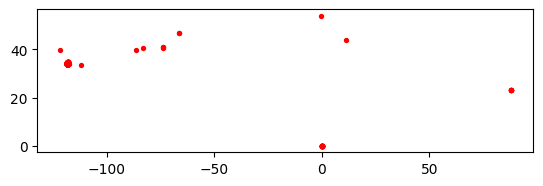

In [0]:
ax = district_1.plot(
    color="lightblue",
    edgecolor="blue"
)

parking_gdf.plot(
    ax=ax,
    color="red",
    markersize=8
)

### Step 8: Validate Point-in-Polygon Matching

Before assigning all citations to districts, test the spatial relationship against a single City Council district.

A point-in-polygon operation determines whether each parking citation location falls within the District 1 boundary.

In [0]:
district_1_tickets = gpd.sjoin(
    parking_gdf,
    district_1[["District", "geometry"]],
    how="inner",
    predicate="within"
)

district_1_tickets.head()

,ticket_number,issue_date,issue_time,issue_time_24h,issue_hour,issue_minute,meter_id,marked_time,rp_state_plate,plate_expiry_date,vin_masked,make,body_style,color,location,route,agency,violation_code,violation_description,fine_amount,agency_desc,color_desc,body_style_desc,loc_lat,loc_long,geometry,index_right,District
2,4602691435,2025-05-01,1211.0,1211,12,11,None,0000,CA,202505,None,LEXS,PA,WT,2800 SAN MARINO ST,None,54.0,80.69BS,NO PARK/STREET CLEAN,73.0,54 - DOT - HOLLYWOOD,WHITE,PASSENGER CAR,34.054988,-118.289699,POINT (-118.2897 34.05499),0,1
5,4602810774,2025-05-01,918.0,0918,9,18,None,0000,CA,0,None,FORD,PA,WT,1831 BONNIE BRAE ST S,None,56.0,80.69BS,NO PARK/STREET CLEAN,73.0,56 - DOT - CENTRAL,WHITE,PASSENGER CAR,34.040415,-118.283423,POINT (-118.28342 34.04041),0,1
6,4602810645,2025-05-01,838.0,0838,8,38,None,0000,CA,0,None,FIAT,PA,RD,1359 BONNIE BRAE ST S,None,56.0,80.69BS,NO PARK/STREET CLEAN,73.0,56 - DOT - CENTRAL,RED,PASSENGER CAR,34.045288,-118.280837,POINT (-118.28084 34.04529),0,1
12,4602392642,2025-05-01,825.0,0825,8,25,None,0000,CA,0,None,TOYT,PA,WT,2009 ORCHARD AVE,None,55.0,80.69BS,NO PARK/STREET CLEAN,73.0,55 - DOT - SOUTHERN,WHITE,PASSENGER CAR,34.037816,-118.288270,POINT (-118.28827 34.03782),0,1
24,4602522422,2025-05-01,1445.0,1445,14,45,None,0000,CA,202401,None,CHEV,PA,RD,5033 LINCOLN AVE,None,56.0,22507.8C2,DISABLED PARKING/CROSS HATCH,363.0,56 - DOT - CENTRAL,RED,PASSENGER CAR,34.120453,-118.205943,POINT (-118.20594 34.12045),0,1


In [0]:
len(district_1_tickets)

4163

<Axes: >

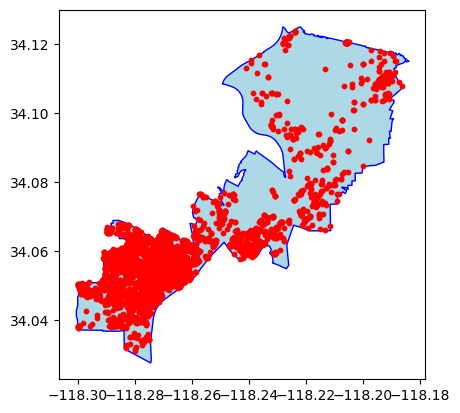

In [0]:
ax = district_1.plot(
    color="lightblue",
    edgecolor="blue"
)

district_1_tickets.plot(
    ax=ax,
    color="red",
    markersize=10
)

### Step 9: Create Gold Layer — Assign All Citations to Council Districts

Apply the validated point-in-polygon logic across all City Council district boundaries to create an enriched, analysis-ready Gold dataset.

Assign each parking citation to its corresponding council district.
Retain the cleaned citation fields from Silver.
Add district identifiers and names for downstream analysis.
Preserve unmatched records for validation rather than silently removing them.

In [0]:
gold_gdf = gpd.sjoin(
    parking_gdf,
    districts_gdf[
        [
            "District",
            "District_Name",
            "geometry"
        ]
    ],
    how="left",
    predicate="within"
)

gold_gdf.head()

,ticket_number,issue_date,issue_time,issue_time_24h,issue_hour,issue_minute,meter_id,marked_time,rp_state_plate,plate_expiry_date,vin_masked,make,body_style,color,location,route,agency,violation_code,violation_description,fine_amount,agency_desc,color_desc,body_style_desc,loc_lat,loc_long,geometry,index_right,District,District_Name
0,4602156160,2025-05-01,1308.0,1308,13,8,None,0000,CA,202508,None,NISS,PA,SL,18300 CANTARA ST,None,53.0,80.58L,PREFERENTIAL PARKING,68.0,53 - DOT - VALLEY,SILVER,PASSENGER CAR,34.219275,-118.532920,POINT (-118.53292 34.21927),3.0,4.0,4 - Nithya Raman
1,4601814361,2025-05-01,851.0,0851,8,51,None,0000,CA,202511,None,VOLK,PA,BK,7225 CRESCENT PARK E,0138B,51.0,80.69BS,NO PARK/STREET CLEAN,73.0,51 - DOT - WESTERN,BLACK,PASSENGER CAR,33.969054,-118.426774,POINT (-118.42677 33.96905),10.0,11.0,11 - Traci Park
2,4602691435,2025-05-01,1211.0,1211,12,11,None,0000,CA,202505,None,LEXS,PA,WT,2800 SAN MARINO ST,None,54.0,80.69BS,NO PARK/STREET CLEAN,73.0,54 - DOT - HOLLYWOOD,WHITE,PASSENGER CAR,34.054988,-118.289699,POINT (-118.2897 34.05499),0.0,1.0,1 - Eunisses Hernandez
3,4602733903,2025-05-01,1240.0,1240,12,40,LM369A,0000,CA,202510,None,MERZ,PA,BK,7200 MELROSE AV,None,54.0,88.13B+,METER EXP.,63.0,54 - DOT - HOLLYWOOD,BLACK,PASSENGER CAR,34.083481,-118.346854,POINT (-118.34685 34.08348),4.0,5.0,5 - Katy Yaroslavsky
4,4601955256,2025-05-01,939.0,0939,9,39,None,0000,TN,202508,None,INFI,PA,GY,21315 ROSCOE BLVD,None,53.0,80.69BS,NO PARK/STREET CLEAN,73.0,53 - DOT - VALLEY,GREY,PASSENGER CAR,34.219973,-118.595759,POINT (-118.59576 34.21997),2.0,3.0,3 - Bob Blumenfield


In [0]:
gold_gdf.dtypes

ticket_number                    object
issue_date               datetime64[ns]
issue_time                      float64
issue_time_24h                   object
issue_hour                        int32
issue_minute                      int32
meter_id                         object
marked_time                      object
rp_state_plate                   object
plate_expiry_date                object
vin_masked                       object
make                             object
body_style                       object
color                            object
location                         object
route                            object
agency                          float64
violation_code                   object
violation_description            object
fine_amount                     float64
agency_desc                      object
color_desc                       object
body_style_desc                  object
loc_lat                         float64
loc_long                        float64


In [0]:
gold_gdf.columns.tolist()


['ticket_number',
 'issue_date',
 'issue_time',
 'issue_time_24h',
 'issue_hour',
 'issue_minute',
 'meter_id',
 'marked_time',
 'rp_state_plate',
 'plate_expiry_date',
 'vin_masked',
 'make',
 'body_style',
 'color',
 'location',
 'route',
 'agency',
 'violation_code',
 'violation_description',
 'fine_amount',
 'agency_desc',
 'color_desc',
 'body_style_desc',
 'loc_lat',
 'loc_long',
 'geometry',
 'index_right',
 'District',
 'District_Name']

In [0]:
gold_pdf = gold_gdf.drop(
    columns=["geometry", "index_right"],
    errors="ignore"
).copy()

gold_pdf["District"] = gold_pdf["District"].astype("Int64")
gold_pdf["agency"] = gold_pdf["agency"].astype("Int64")

gold_pdf["loc_lat"] = gold_pdf["loc_lat"].astype("float64")
gold_pdf["loc_long"] = gold_pdf["loc_long"].astype("float64")

In [0]:
gold_df = spark.createDataFrame(gold_pdf)

gold_df.printSchema()

root
 |-- ticket_number: string (nullable = true)
 |-- issue_date: timestamp (nullable = true)
 |-- issue_time: double (nullable = true)
 |-- issue_time_24h: string (nullable = true)
 |-- issue_hour: integer (nullable = true)
 |-- issue_minute: integer (nullable = true)
 |-- meter_id: string (nullable = true)
 |-- marked_time: string (nullable = true)
 |-- rp_state_plate: string (nullable = true)
 |-- plate_expiry_date: string (nullable = true)
 |-- vin_masked: void (nullable = true)
 |-- make: string (nullable = true)
 |-- body_style: string (nullable = true)
 |-- color: string (nullable = true)
 |-- location: string (nullable = true)
 |-- route: string (nullable = true)
 |-- agency: long (nullable = true)
 |-- violation_code: string (nullable = true)
 |-- violation_description: string (nullable = true)
 |-- fine_amount: double (nullable = true)
 |-- agency_desc: string (nullable = true)
 |-- color_desc: string (nullable = true)
 |-- body_style_desc: string (nullable = true)
 |-- loc_

In [0]:
# gold
gold_df = gold_df.withColumn(
    "vin_masked",
    F.col("vin_masked").cast("string")
)

gold_df.printSchema()

root
 |-- ticket_number: string (nullable = true)
 |-- issue_date: timestamp (nullable = true)
 |-- issue_time: double (nullable = true)
 |-- issue_time_24h: string (nullable = true)
 |-- issue_hour: integer (nullable = true)
 |-- issue_minute: integer (nullable = true)
 |-- meter_id: string (nullable = true)
 |-- marked_time: string (nullable = true)
 |-- rp_state_plate: string (nullable = true)
 |-- plate_expiry_date: string (nullable = true)
 |-- vin_masked: string (nullable = true)
 |-- make: string (nullable = true)
 |-- body_style: string (nullable = true)
 |-- color: string (nullable = true)
 |-- location: string (nullable = true)
 |-- route: string (nullable = true)
 |-- agency: long (nullable = true)
 |-- violation_code: string (nullable = true)
 |-- violation_description: string (nullable = true)
 |-- fine_amount: double (nullable = true)
 |-- agency_desc: string (nullable = true)
 |-- color_desc: string (nullable = true)
 |-- body_style_desc: string (nullable = true)
 |-- lo

In [0]:
%sql
DROP TABLE IF EXISTS parking_citations_gold;

In [0]:
gold_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("parking_citations_gold")

In [0]:
%sql
SELECT
    ticket_number,
    issue_date,
    issue_time_24h,
    location,
    loc_lat,
    loc_long,
    violation_code,
    violation_description,
    fine_amount,
    District,
    District_Name
FROM parking_citations_gold
LIMIT 10;

ticket_number,issue_date,issue_time_24h,location,loc_lat,loc_long,violation_code,violation_description,fine_amount,District,District_Name
4602450893,2025-05-03T00:00:00.000Z,1447,4715 SPEEDWAY,33.97040529,-118.45892448,5200,DISPLAY OF PLATES,25.0,11,11 - Traci Park
4602415296,2025-05-03T00:00:00.000Z,1618,5201 HERMITAGE AVE,34.1651347,-118.4004456,22514,FIRE HYDRANT,68.0,2,2 - Adrin Nazarian
4601776071,2025-05-03T00:00:00.000Z,1613,12444 VENICE BL,34.00292383,-118.43476373,88.13B+,METER EXP.,63.0,11,11 - Traci Park
4602274611,2025-05-03T00:00:00.000Z,1543,8111 VENTURA CANYON AV,34.2184298,-118.4292819,22500.1+,PARKED IN FIRE LANE,63.0,6,6 - Imelda Padilla
4602836350,2025-05-03T00:00:00.000Z,1736,14227 MAGNOLIA BL,34.1650179,-118.4431575,88.66,ELECTRIC CHARGING STATION SPACES,58.0,4,4 - Nithya Raman
4602420292,2025-05-03T00:00:00.000Z,1458,123 AVE 57 N,34.110163,-118.1930174,88.63B+,OFF STR/OVERTIME/MTR,58.0,1,1 - Eunisses Hernandez
4602988961,2025-05-03T00:00:00.000Z,1331,352 FLORES ST N,34.07781853,-118.37114767,80.58L,PREFERENTIAL PARKING,68.0,5,5 - Katy Yaroslavsky
4602680633,2025-05-03T00:00:00.000Z,1719,300 12TH ST W,33.73374316,-118.28551061,80.61,STANDNG IN ALLEY,68.0,15,15 - Tim McOsker
4602863031,2025-05-03T00:00:00.000Z,1523,12101 VENTURA BL,34.1434596,-118.3969152,88.13B+,METER EXP.,63.0,4,4 - Nithya Raman
4602221120,2025-05-03T00:00:00.000Z,1606,6207 MULHOLLAND HWY W,34.129176,-118.3227405,80.58L,PREFERENTIAL PARKING,68.0,4,4 - Nithya Raman
